# PROB: Open-World Object Detection — Single Image Inference

Run this notebook in **Google Colab** (GPU runtime required).

> **Runtime → Change runtime type → T4 GPU** before running.

## Cell 1 — Clone repo & install dependencies

In [6]:
!python -m pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
import os

# Clone YOUR fork (has the COCO_INC training code)
if not os.path.exists("PROB"):
    !git clone https://github.com/VarVilmos/PROB
elif os.path.exists("PROB/.git"):
    # Already cloned — pull latest changes
    !git -C PROB pull

%cd /content/PROB

# Force uninstall old torch to avoid version conflicts
!pip uninstall -y torch torchvision torchaudio

# Install requirements first (before PyTorch, so PyTorch is not downgraded)
!pip install -q -r requirements.txt

# Install PyTorch compatible with Colab CUDA 12.x (overwrites any torch from requirements.txt)
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121

# Verify GPU is available and check versions
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch CUDA version: {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}")

## Cell 2 — Compile CUDA ops (MultiScaleDeformableAttention)

In [8]:
!pip install -q ninja

import os, sys, importlib, glob

os.chdir("/content/PROB/models/ops")
!rm -rf build/ dist/ MultiScaleDeformableAttention.egg-info

!{sys.executable} setup.py build install

importlib.invalidate_caches()

# Find the compiled .so and add its directory to sys.path
so_files = glob.glob("/content/PROB/models/ops/build/lib*/*.so")
for so in so_files:
    parent = os.path.dirname(so)
    if parent not in sys.path:
        sys.path.insert(0, parent)
        print(f"Added to sys.path: {parent}")

try:
    import MultiScaleDeformableAttention
    print("Success: MultiScaleDeformableAttention compiled and imported!")
except ImportError as e:
    print(f"Import failed: {e}")
    print("Found .so files:", so_files)

os.chdir("/content/PROB")


running build
running build_py
creating build/lib.linux-x86_64-cpython-312/modules
copying modules/ms_deform_attn.py -> build/lib.linux-x86_64-cpython-312/modules
copying modules/__init__.py -> build/lib.linux-x86_64-cpython-312/modules
creating build/lib.linux-x86_64-cpython-312/functions
copying functions/__init__.py -> build/lib.linux-x86_64-cpython-312/functions
copying functions/ms_deform_attn_func.py -> build/lib.linux-x86_64-cpython-312/functions
running build_ext
/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py:416: UserWarning: The detected CUDA version (12.8) has a minor version mismatch with the version that was used to compile PyTorch (12.1). Most likely this shouldn't be a problem.
  warnings.warn(CUDA_MISMATCH_WARN.format(cuda_str_version, torch.version.cuda))
/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py:426: UserWarning: There are no x86_64-linux-gnu-g++ version bounds defined for CUDA version 12.8
  warnings.warn(f'There are n

## Cell 3 — Download backbone weights & PROB checkpoint

This downloads:
- DINO ResNet-50 backbone pretrained weights
- PROB Task-1 checkpoint trained on MOWODB (20 known classes + unknown)

The checkpoint link below is from the PROB paper's official release. If the Google Drive link is broken, replace it with an updated one from https://github.com/orrzohar/PROB

In [9]:
import os, zipfile
!pip install -q gdown
import gdown

# --- Backbone ---
os.makedirs("models", exist_ok=True)
backbone_path = "models/dino_resnet50_pretrain.pth"
if not os.path.exists(backbone_path):
    print("Downloading DINO ResNet-50 backbone...")
    !wget -q https://dl.fbaipublicfiles.com/dino/dino_resnet50_pretrain/dino_resnet50_pretrain.pth -O {backbone_path}
    print("Done.")
else:
    print("Backbone already downloaded.")

# --- PROB checkpoints ---
# The Google Drive file is a ZIP containing SOWODB/ and MOWODB/ checkpoints.
# We download it once and extract what we need.
zip_path = "exps/PROB_checkpoints.zip"
os.makedirs("exps", exist_ok=True)

def is_valid_zip(path):
    if not os.path.exists(path):
        return False
    with open(path, "rb") as f:
        return f.read(4) == b"PK\x03\x04"

if not is_valid_zip(zip_path):
    print("Downloading PROB checkpoints ZIP (~3.5 GB)...")
    gdown.download(id="1TbSbpeWxRp1SGcp660n-35sd8F8xVBSq", output=zip_path, fuzzy=True)
else:
    print(f"Checkpoint ZIP already downloaded ({os.path.getsize(zip_path)/1e6:.0f} MB)")

# Extract the checkpoints we need
with zipfile.ZipFile(zip_path) as zf:
    for dataset in ["MOWODB", "SOWODB"]:
        for task in ["t1", "t2", "t3", "t4"]:
            src = f"{dataset}/{task}.pth"
            dst_dir = f"exps/{dataset}/PROB"
            dst = f"{dst_dir}/{task}.pth"
            os.makedirs(dst_dir, exist_ok=True)
            if not os.path.exists(dst):
                print(f"Extracting {src} ...")
                with zf.open(src) as src_f, open(dst, "wb") as dst_f:
                    dst_f.write(src_f.read())
            else:
                print(f"Already extracted: {dst}")

ckpt_path = "exps/MOWODB/PROB/t1.pth"
print(f"\nUsing checkpoint: {ckpt_path} ({os.path.getsize(ckpt_path)/1e6:.0f} MB)")


Done.


Downloading...
From (original): https://drive.google.com/uc?id=1TbSbpeWxRp1SGcp660n-35sd8F8xVBSq
From (redirected): https://drive.google.com/uc?id=1TbSbpeWxRp1SGcp660n-35sd8F8xVBSq&confirm=t&uuid=538ca9d5-6409-4f78-b823-c6a3ef7ba94e
To: /content/PROB/exps/PROB_checkpoints.zip
100%|██████████| 3.53G/3.53G [00:45<00:00, 77.7MB/s]


Extracting MOWODB/t1.pth ...
Extracting MOWODB/t2.pth ...
Extracting MOWODB/t3.pth ...
Extracting MOWODB/t4.pth ...
Extracting SOWODB/t1.pth ...
Extracting SOWODB/t2.pth ...
Extracting SOWODB/t3.pth ...
Extracting SOWODB/t4.pth ...

Using checkpoint: exps/MOWODB/PROB/t1.pth (479 MB)


## Cell 4 — Build model & load weights

In [10]:
import subprocess
result = subprocess.run(['find', '/content', '-name', 't1.pth'], capture_output=True, text=True)
print(result.stdout)

/content/PROB/exps/MOWODB/PROB/t1.pth
/content/PROB/exps/SOWODB/PROB/t1.pth



In [11]:
import sys, os
import torch

# Validate checkpoint before loading
CKPT_PATH = "exps/MOWODB/PROB/t1.pth"
if os.path.exists(CKPT_PATH):
    size_mb = os.path.getsize(CKPT_PATH) / 1e6
    with open(CKPT_PATH, "rb") as f:
        magic = f.read(4)
    valid = magic == b"PK\x03\x04"
    print(f"Checkpoint: {size_mb:.1f} MB, valid={valid}, magic={magic}")
    if not valid:
        print("Checkpoint is corrupted (not a PyTorch file). Re-run Cell 3 to re-download.")
        raise RuntimeError("Invalid checkpoint — re-run Cell 3")
else:
    print("Checkpoint file not found — run Cell 3 first.")
    raise FileNotFoundError(CKPT_PATH)

# Make sure repo root is on the path
if "." not in sys.path:
    sys.path.insert(0, ".")

from main_open_world import get_args_parser
from models import build_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

args = get_args_parser().parse_args([
    "--dataset", "TOWOD",
    "--PREV_INTRODUCED_CLS", "0",
    "--CUR_INTRODUCED_CLS", "20",
    "--model_type", "prob",
    "--obj_temp", "1.3",
    "--resume", CKPT_PATH,
    "--device", DEVICE,
    "--eval",
])

model, criterion, postprocessors, exemplar_selection = build_model(args, mode="prob")

checkpoint = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
missing, unexpected = model.load_state_dict(checkpoint["model"], strict=False)
if missing:
    print(f"Missing keys: {missing}")
if unexpected:
    print(f"Unexpected keys: {unexpected}")

model.eval().to(DEVICE)
print("Model loaded successfully.")


Checkpoint: 478.7 MB, valid=True, magic=b'PK\x03\x04'
{'OWDETR': ('aeroplane', 'bicycle', 'bird', 'boat', 'bus', 'car', 'cat', 'cow', 'dog', 'horse', 'motorbike', 'sheep', 'train', 'elephant', 'bear', 'zebra', 'giraffe', 'truck', 'person', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'chair', 'diningtable', 'pottedplant', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'bed', 'toilet', 'sofa', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'tvmonitor', 'bottle', 'unknown'), 'TOWOD': ('aeroplane', 'bicycle', 'bird', 'boat', 'bottle

/content/PROB/models/ops/modules/ms_deform_attn.py:83: SyntaxWarning: invalid escape sequence '\s'
  :param input_flatten               (N, \sum_{l=0}^{L-1} H_l \cdot W_l, C)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/content/PROB/models/backbone.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorc

running with exemplar_replay_selection
Model loaded successfully.


## Cell 5 — Upload image & run inference

Upload any photo (JPG/PNG). The model detects both **known classes** (VOC/COCO categories) and **unknown objects**.

Select an image file to upload:


Saving Screenshot 2026-03-31 184402.png to Screenshot 2026-03-31 184402.png
Image loaded: Screenshot 2026-03-31 184402.png | size: (493, 374)

Detected 11 object(s) above threshold 0.3
  cow: 0.720
  unknown: 0.659
  unknown: 0.637
  unknown: 0.637
  unknown: 0.564
  unknown: 0.422
  unknown: 0.381
  unknown: 0.373
  unknown: 0.370
  unknown: 0.363
  unknown: 0.349


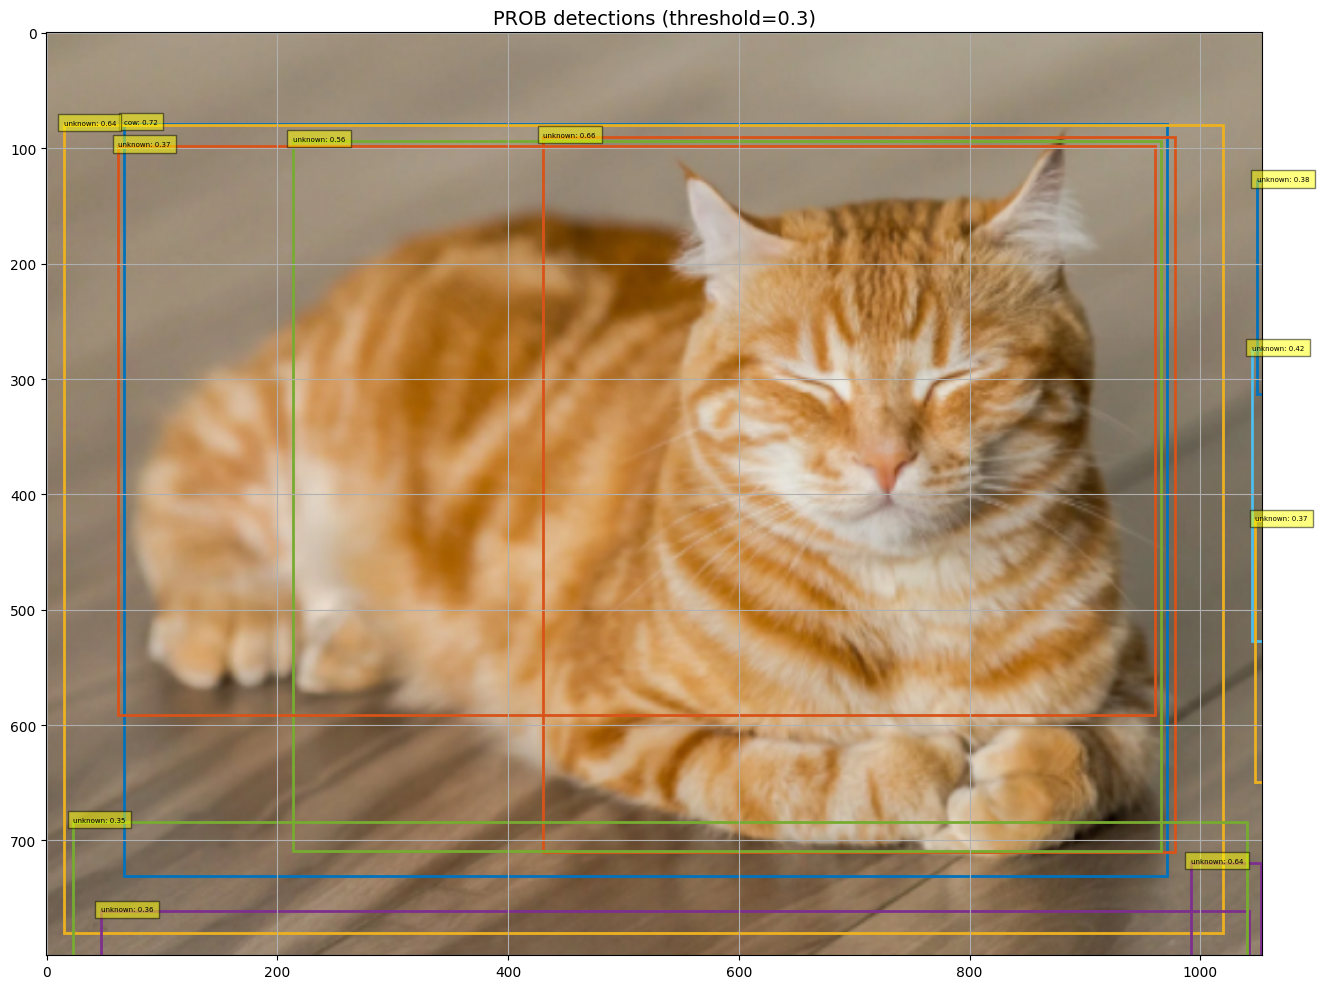

Saved to output.jpg


In [15]:
import PIL.Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from google.colab import files
from util.misc import nested_tensor_from_tensor_list
from util.plot_utils import CLASSES, COLORS, plot_results

# --- Upload image ---
print('Select an image file to upload:')
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
img = PIL.Image.open(img_path).convert('RGB')
print(f'Image loaded: {img_path} | size: {img.size}')

# --- Preprocessing (matches training transforms) ---
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
img_tensor = transform(img).to(DEVICE)  # [3, H, W]

# --- Inference ---
h, w = img_tensor.shape[-2], img_tensor.shape[-1]
orig_sizes = torch.tensor([[h, w]]).to(DEVICE)

with torch.no_grad():
    samples = nested_tensor_from_tensor_list([img_tensor])
    outputs = model(samples)
    results = postprocessors['bbox'](outputs, orig_sizes)

scores = results[0]['scores'].cpu()
boxes  = results[0]['boxes'].cpu()
labels = results[0]['labels'].cpu()

# --- Filter by confidence threshold ---
THRESHOLD = 0.3
keep = scores > THRESHOLD
n_det = keep.sum().item()
print(f'\nDetected {n_det} object(s) above threshold {THRESHOLD}')

# Show detected class names
for sc, lb in zip(scores[keep], labels[keep]):
    cls_name = CLASSES[lb] if lb < len(CLASSES) else f'class_{lb}'
    print(f'  {cls_name}: {sc:.3f}')

# --- Visualise ---
# Convert tensor image back to numpy for plot_results (expects HWC, unnormalised)
img_np = img_tensor.cpu().permute(1, 2, 0).numpy()

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
plot_results(img_np, scores[keep], boxes[keep], labels[keep], ax)
ax.set_title(f'PROB detections (threshold={THRESHOLD})', fontsize=14)
plt.tight_layout()
plt.savefig('output.jpg', bbox_inches='tight', dpi=150)
plt.show()
print('Saved to output.jpg')

## Cell 6 — Download result image

In [17]:
from google.colab import files
files.download('output.jpg')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Optional: adjust confidence threshold

Re-run just the visualisation with a different threshold (no re-inference needed).

Detected 11 object(s) above threshold 0.3


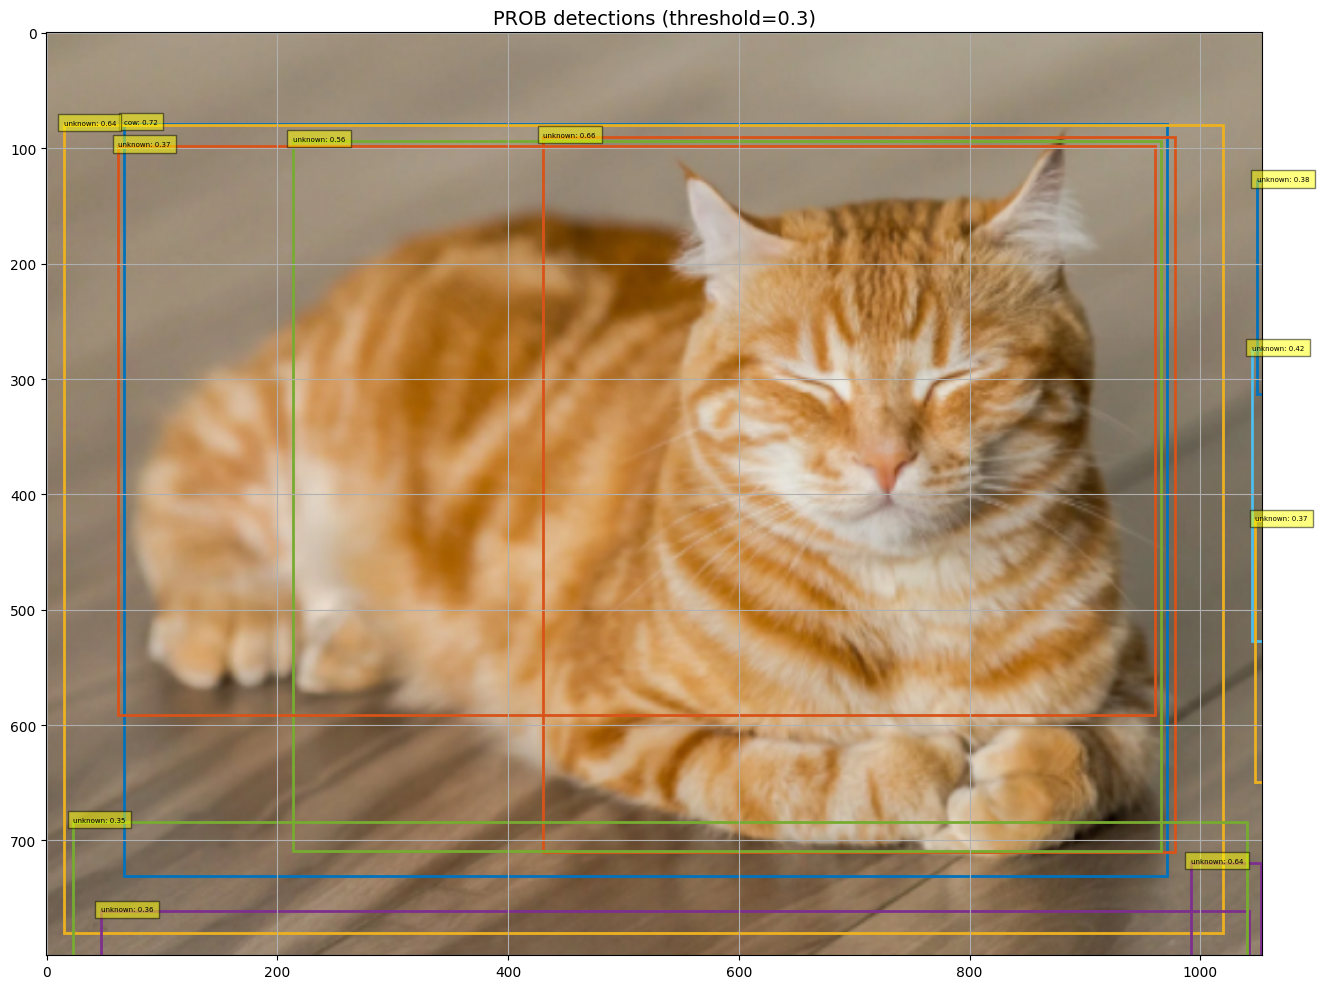

In [19]:
NEW_THRESHOLD = 0.3  # <-- change this

keep2 = scores > NEW_THRESHOLD
print(f'Detected {keep2.sum().item()} object(s) above threshold {NEW_THRESHOLD}')

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
plot_results(img_np, scores[keep2], boxes[keep2], labels[keep2], ax)
ax.set_title(f'PROB detections (threshold={NEW_THRESHOLD})', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
from util.plot_utils import CLASSES
for i, cls in enumerate(CLASSES):
    print(f"{i}: {cls}")

0: aeroplane
1: bicycle
2: bird
3: boat
4: bus
5: car
6: cat
7: cow
8: dog
9: horse
10: motorbike
11: sheep
12: train
13: elephant
14: bear
15: zebra
16: giraffe
17: truck
18: person
19: traffic light
20: fire hydrant
21: stop sign
22: parking meter
23: bench
24: chair
25: diningtable
26: pottedplant
27: backpack
28: umbrella
29: handbag
30: tie
31: suitcase
32: microwave
33: oven
34: toaster
35: sink
36: refrigerator
37: bed
38: toilet
39: sofa
40: frisbee
41: skis
42: snowboard
43: sports ball
44: kite
45: baseball bat
46: baseball glove
47: skateboard
48: surfboard
49: tennis racket
50: banana
51: apple
52: sandwich
53: orange
54: broccoli
55: carrot
56: hot dog
57: pizza
58: donut
59: cake
60: laptop
61: mouse
62: remote
63: keyboard
64: cell phone
65: book
66: clock
67: vase
68: scissors
69: teddy bear
70: hair drier
71: toothbrush
72: wine glass
73: cup
74: fork
75: knife
76: spoon
77: bowl
78: tvmonitor
79: bottle
80: unknown


In [ ]:
## Training Cell D — Full 8-task COCO_INC benchmark (runs all tasks sequentially)
# WARNING: This takes many hours. Colab may disconnect — checkpoints are saved automatically.
# If it disconnects, re-run setup cells (A-C already done), then resume from the last checkpoint.

import os
os.chdir("/content/PROB")

!bash configs/COCO_INC_BENCHMARK.sh

In [ ]:
## Training Cell C — Train Task 1 (smoke test, 5 epochs, ~15 min)
# Trains on classes 0-9 only. If this completes without errors, the full pipeline works.
# After this succeeds, run Cell D for the full 8-task run.

import os
os.chdir("/content/PROB")

!python main_open_world.py \
    --output_dir exps/COCO_INC/PROB/t1 \
    --dataset COCO_INC \
    --PREV_INTRODUCED_CLS 0 --CUR_INTRODUCED_CLS 10 \
    --train_set coco_inc_t1_train \
    --test_set coco_inc_all_test \
    --epochs 5 \
    --model_type prob \
    --obj_loss_coef 8e-4 \
    --obj_temp 1.3 \
    --num_workers 2 \
    --batch_size 2

In [ ]:
## Training Cell B — Generate COCO_INC split files (run once after dataset download)
# Scans all XML annotations and creates per-task image lists in data/OWOD/ImageSets/COCO_INC/

import os
os.chdir("/content/PROB")
!python datasets/generate_coco_inc_splits.py
print("Split files ready.")

In [ ]:
## Training Cell A — Download OWOD Dataset (~20 GB, run once)
# Sources: COCO 2017 (train+val) + Pascal VOC 2007+2012
# After extraction the zips/tars are deleted to save disk space.
# Colab disk available: ~70 GB — this uses ~20 GB after cleanup.

import os
os.chdir("/content/PROB")

COCO_DIR  = "data/coco"
OWOD_IMGS = "data/OWOD/JPEGImages"
OWOD_ANN  = "data/OWOD/Annotations"

os.makedirs(COCO_DIR,  exist_ok=True)
os.makedirs(OWOD_IMGS, exist_ok=True)
os.makedirs(OWOD_ANN,  exist_ok=True)

# ── COCO 2017 ──────────────────────────────────────────────────────────────
print("=== Downloading COCO 2017 train (~18 GB) ===")
if not os.path.exists(f"{COCO_DIR}/train2017"):
    !wget -q --show-progress http://images.cocodataset.org/zips/train2017.zip -P {COCO_DIR}
    !unzip -q {COCO_DIR}/train2017.zip -d {COCO_DIR}
    !rm {COCO_DIR}/train2017.zip
    print("Done.")
else:
    print("train2017 already extracted.")

print("=== Downloading COCO 2017 val (~1 GB) ===")
if not os.path.exists(f"{COCO_DIR}/val2017"):
    !wget -q --show-progress http://images.cocodataset.org/zips/val2017.zip -P {COCO_DIR}
    !unzip -q {COCO_DIR}/val2017.zip -d {COCO_DIR}
    !rm {COCO_DIR}/val2017.zip
    print("Done.")
else:
    print("val2017 already extracted.")

print("=== Downloading COCO annotations (~1 GB) ===")
if not os.path.exists(f"{COCO_DIR}/annotations"):
    !wget -q --show-progress http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P {COCO_DIR}
    !unzip -q {COCO_DIR}/annotations_trainval2017.zip -d {COCO_DIR}
    !rm {COCO_DIR}/annotations_trainval2017.zip
    print("Done.")
else:
    print("annotations already extracted.")

# Move COCO images into OWOD/JPEGImages
print("=== Moving COCO images into OWOD folder ===")
!find {COCO_DIR}/train2017 -name "*.jpg" | xargs -I{{}} mv {{}} {OWOD_IMGS}/ 2>/dev/null || true
!find {COCO_DIR}/val2017   -name "*.jpg" | xargs -I{{}} mv {{}} {OWOD_IMGS}/ 2>/dev/null || true
print(f"Images in OWOD/JPEGImages: {len(os.listdir(OWOD_IMGS))}")

# Convert COCO JSON annotations → VOC XML
print("=== Converting COCO annotations to VOC XML ===")
!python datasets/coco2voc.py
print("Done.")

# ── Pascal VOC 2007 ────────────────────────────────────────────────────────
print("=== Downloading Pascal VOC 2007 (~900 MB) ===")
if not os.path.exists("VOCdevkit/VOC2007"):
    !wget -q --show-progress http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
    !wget -q --show-progress http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtest_06-Nov-2007.tar
    !tar -xf VOCtrainval_06-Nov-2007.tar && rm VOCtrainval_06-Nov-2007.tar
    !tar -xf VOCtest_06-Nov-2007.tar     && rm VOCtest_06-Nov-2007.tar
    print("Done.")
else:
    print("VOC2007 already extracted.")

# ── Pascal VOC 2012 ────────────────────────────────────────────────────────
print("=== Downloading Pascal VOC 2012 (~2 GB) ===")
if not os.path.exists("VOCdevkit/VOC2012"):
    !wget -q --show-progress http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
    !tar -xf VOCtrainval_11-May-2012.tar && rm VOCtrainval_11-May-2012.tar
    print("Done.")
else:
    print("VOC2012 already extracted.")

# Move VOC images + annotations into OWOD folder
print("=== Moving VOC images and annotations into OWOD folder ===")
!find VOCdevkit/VOC2007/JPEGImages -name "*.jpg" | xargs -I{{}} mv {{}} {OWOD_IMGS}/ 2>/dev/null || true
!find VOCdevkit/VOC2012/JPEGImages -name "*.jpg" | xargs -I{{}} mv {{}} {OWOD_IMGS}/ 2>/dev/null || true
!find VOCdevkit/VOC2007/Annotations -name "*.xml" | xargs -I{{}} mv {{}} {OWOD_ANN}/ 2>/dev/null || true
!find VOCdevkit/VOC2012/Annotations -name "*.xml" | xargs -I{{}} mv {{}} {OWOD_ANN}/ 2>/dev/null || true

print(f"\nTotal images : {len(os.listdir(OWOD_IMGS))}")
print(f"Total XMLs   : {len(os.listdir(OWOD_ANN))}")
print("Dataset ready.")

---
## COCO_INC Training — Class-Incremental Learning (10 classes × 8 tasks)

Run the cells below **in order** to train PROB with the new 8-task incremental protocol.

**Steps:**
1. Download OWOD dataset (~20 GB — only needed once)
2. Generate COCO_INC split files
3. Train Task 1 (classes 0–9) as a smoke test
4. Run the full 8-task benchmark